## 3.8. Pretrained models

* A common and highly effective approach to deep learning on small image datasets is to use a pretrained model.
* A pretrained model is a model that was previously trained on a large dataset, typically on a large-scale image-classification task. 
* If this original dataset is large enough and general enough, the spatial hierarchy of features learned by the pretrained model can prove useful for many different computer vision problems.
* Such portability of learned features across different problems is a key advantage of deep learning compared to many older, shallow learning approaches, and it makes deep learning very effective for small-data problems.
* There are two ways to use a pretrained model: __feature extraction__ and __fine-tuning__.

### 3.8.1. Feature extraction 

* Feature extraction consists of using the representations learned by a previously trained model to extract interesting features from new samples. 
* We freeze the weights in the feature extraction layer so they don't change in the new training process.
* These features are then run through a new classifier, which is trained from scratch.

![feature_extraction_pretrained_model%20_horizontal.png](images/CNNs/feature_extraction_pretrained_model%20_horizontal.png)

#### Example

* Let's load the small cats-vs-dogs dataset again

In [1]:
import keras
from keras import layers

In [2]:
import os, shutil, pathlib
base_dir = pathlib.Path("C:/datasets/dogs-vs-cats_small")

from keras.utils import image_dataset_from_directory
train_dataset = image_dataset_from_directory(
    base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


#### Use of pretrained models

* We’ll use the VGG16 architecture, developed by Karen Simonyan and Andrew Zisserman in 2014.
* This architecture was trained on the ImageNet dataset (1.4 million labeled images and 1,000 different classes). 
* ImageNet contains many animal classes, including different species of cats and dogs, and you can thus expect it to perform well on the dogs-vs-cats classification problem.
* The VGG16 model, among others, comes prepackaged with Keras and can be imported from the `keras.applications` module. 
* Many other image-classification models (all pretrained on the ImageNet dataset) are available as part of `keras.applications`: Xception, ResNet, MobileNet, EfficientNet, DenseNet, etc.

* We pass the following arguments to the constructor of `VGG16`:
    - `weights` specifies the weight checkpoint from which to initialize the model. I we choose `"None"` the we would obtain a random initialization. If we choose `"imagenet"` we would obtain the pre-trained weights on ImageNet dataset.
    - `include_top` refers to including (or not) the densely connected classifier on top of the network. By default, this densely connected classifier corresponds to the 1,000 classes from ImageNet. Because we intend to use our own densely connected classifier (with only two classes: cat and dog), we don’t need to include it.
    - `input_shape` is the shape of the image tensors that we’ll feed to the network. This argument is purely optional: if we don’t pass it, the network will be able to process inputs of any size. Here we pass it so that we can visualize (in the following summary) how the size of the feature maps shrinks with each new convolution and pooling layer.

In [3]:
# Instantiating the VGG16 convolutional base
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

In [4]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

C:\Users\eduar\anaconda3\envs\AP\Lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


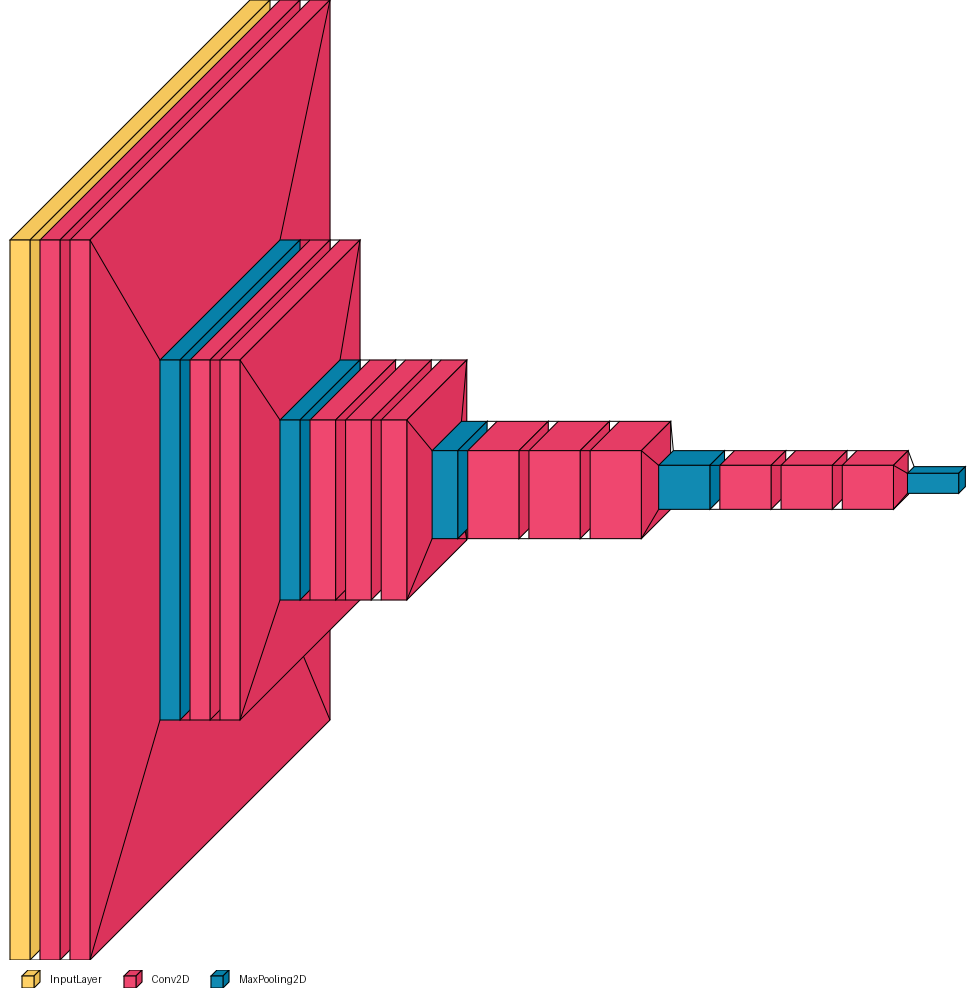

In [5]:
import visualkeras
visualkeras.layered_view(conv_base, legend=True)

#### Fast feature extraction without data augmentation

* We can now run the convolutional base over our dataset, record its output to a NumPy array on disk, and then use this data as input to a standalone, densely connected classifier.
* This solution is fast and cheap to run, because it only requires running the convolutional base once for every input image, and the convolutional base is by far the most expensive part of the pipeline.
* But for the same reason, this technique won’t allow us to use data augmentation.
* We’ll start by extracting features as NumPy arrays by calling the `predict()` method of the `conv_base` model on our training, validation, and testing datasets.
* Keras Application input preprocessing
    - Keras Applications models require you to preprocess images before passing them to the model.
    - This is important, since you need the inputs you provide to match the value range that the pretrained layers expect.

In [6]:
import numpy as np
  
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)
  
train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━

* The extracted features are currently of shape `(samples, 5, 5, 512)`, that is the shape of our final `feature_map` (that's the feature map on top of which we'll stick a densely connected classifier.

In [7]:
train_features.shape

(2000, 5, 5, 512)

* At this point, we can define our densely connected classifier and train it on the data and labels that we just recorded.
* Training will very fast because we only have to deal with two `Dense` layers.

In [8]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])
  
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8672 - loss: 26.5903 - val_accuracy: 0.9440 - val_loss: 7.9856
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9772 - loss: 2.7303 - val_accuracy: 0.9740 - val_loss: 4.6267
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9865 - loss: 1.1036 - val_accuracy: 0.9750 - val_loss: 4.6441
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9928 - loss: 0.6710 - val_accuracy: 0.9650 - val_loss: 7.1174
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9872 - loss: 1.2175 - val_accuracy: 0.9750 - val_loss: 3.4524
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9907 - loss: 1.1791 - val_accuracy: 0.9660 - val_loss: 5.3896
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9963 - loss: 0.3560 - val_accuracy: 0.9670 - val_loss: 5.8867
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9945 - loss: 0.4941 - val_accuracy: 0.9670 - 

In [9]:
import matplotlib.pyplot as plt

def plot(history):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "b-o", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "r--o", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "b-o", label="Training loss")
    plt.plot(epochs, val_loss, "r--o", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

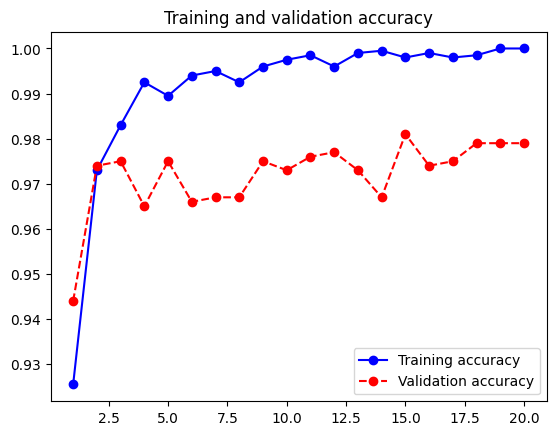

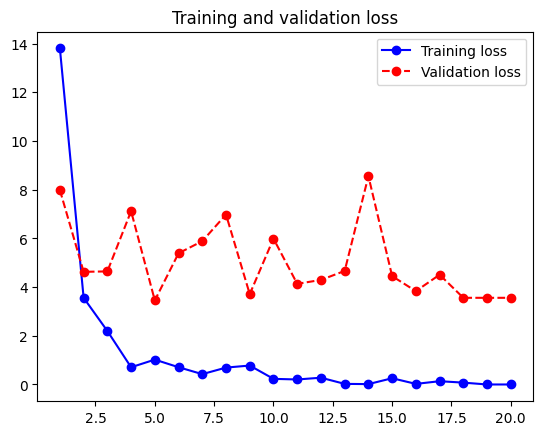

In [10]:
plot(history)

* We reach a validation accuracy of about 97%, much better than we achieved with the small model trained from scratch.
* But we have to take into account that ImageNet contains many dog and cat instances, which means that our pretrained model already has the exact knowledge required for the task at hand. This won’t always be the case when you use pretrained features.
* The plots also indicate that we’re overfitting almost from the start—despite using dropout with a fairly large rate.
* That’s because this technique doesn’t use data augmentation, which is essential for preventing overfitting with small image datasets.

#### Feature extraction together with data augmentation

* We are going to extend the model we have (`conv_base`) by adding Dense layers on top, and run the whole thing from end to end on the input data.
* This will allow us to use data augmentation, because every input image goes through the convolutional base every time it’s seen by the model.
* But for the same reason, this technique is far more expensive than the first.
* Our first step will be __to freeze the convolutional base__.

* __Freezing the convolutional base__:
    * Layers & models have a boolean attribute `trainable`. 
    * Setting `layer.trainable` to `False` moves all the layer's weights from trainable to non-trainable. 
    * This is called "_freezing_" the layer, the state of a frozen layer won't be updated during training.
    * If you set `trainable = False` on a model or on any layer that has sublayers, all children layers become non-trainable as well.

* __Example__
    - In our example the network has 14,714,688 parameters, all of the trainable, that is they are meant to be updated (via gradient descent) to minimize the loss during training.
    - In general, all weights are trainable weights.
    - Non-trainable weights aren't meant to be trained and typically they are updated by the model during the forward pass.
    - For example, the `BatchNormalization` layer uses non-trainable weights to keep track of the mean and variance of its inputs during training.

In [11]:
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)

In [12]:
conv_base.trainable = False

In [13]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
from keras import layers
from keras.layers import RandomFlip, RandomRotation, RandomZoom

In [15]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)
  
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x) 
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

* With this setup, only the weights from the two `Dense` layers that we added will be trained.
* Thanks to data augmentation, it will take much longer for the model to start overfitting, so we can train for more epochs (50).
* Note that in order for these changes to take effect, you must first compile the model.
* If you ever modify weight trainability after compilation, you should then recompile the model, or these changes will be ignored.

In [16]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="models/U3-CNNs/dogs-vs-cats_FE_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50, 
    validation_data=validation_dataset, 
    callbacks=callbacks) 

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8193 - loss: 27.0588 - val_accuracy: 0.9740 - val_loss: 4.2147
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9526 - loss: 4.8375 - val_accuracy: 0.9680 - val_loss: 4.2545
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9460 - loss: 5.6655 - val_accuracy: 0.9780 - val_loss: 2.0227
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9606 - loss: 3.9997 - val_accuracy: 0.9770 - val_loss: 2.4336
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9710 - loss: 2.3222 - val_accuracy: 0.9780 - val_loss: 2.6651
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9707 - loss: 1.9059 - val_accuracy: 0.9760 - val_loss: 2.8568
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9762 - loss: 3.2239 - val_accuracy: 0.9810 - val_loss: 2.5838
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9769 - loss: 2.1811 - val_accuracy: 0.9800 - val_los

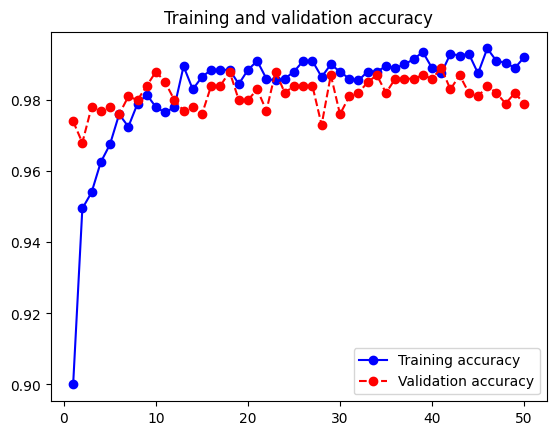

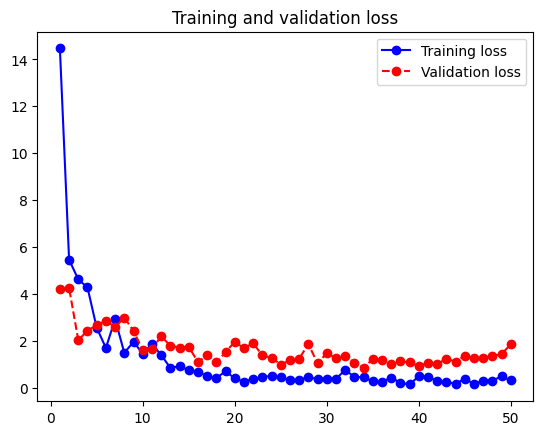

In [17]:
plot(history)

In [18]:
test_model = keras.models.load_model("models/U3-CNNs/dogs-vs-cats_FE_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 942ms/step - accuracy: 0.9756 - loss: 1.4521
Test accuracy: 0.975


### 3.8.2 Fine-tuning

* Fine-tuning consists of unfreezing a few of the top layers of a frozen model base used for feature extraction.
* Then jointly train both these top layers and the added part (the fully connected classifier). 
* It is called fine-tuning because it slightly adjusts the more abstract features reused in order to make them more relevant for the problem at hand.

![fine-tunning-pretrained-model_horizontal.png](images/CNNs/fine-tunning-pretrained-model_horizontal.png)

* The steps for fine-tuning a network are as follows:

1. Add our custom network on top of an already-trained base network.
2. Freeze the base network.
3. Train the part we added.

* This are the same steps as in feature extraction:
    * We need to train the classifier part before fine-tuning.
    * Otherwise the error signal during training will be too large and it will destroy the features already learned in the layer we are going to fine-tune.

4. Unfreeze some layers in the base network. 
5. Jointly train both those layers and the classifier added (again).

In [19]:
# Make the last layers trainable
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [20]:
# Summary of our model
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

* We’ll use a very low learning rate (`1e-5`) when fine-tuning our model. 
* The reason for using a low learning rate is that we want to limit the magnitude of the modifications.
* We’re fine-tuning, updates that are too large may harm the features already learned.

In [21]:
# Fine-tuning the model
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])
  
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="models/U3-CNNs/dogs-vs-cats_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30, 
    validation_data=validation_dataset
    , callbacks=callbacks) 

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9877 - loss: 0.5387 - val_accuracy: 0.9810 - val_loss: 1.5130
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9901 - loss: 0.3381 - val_accuracy: 0.9830 - val_loss: 1.2821
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9910 - loss: 0.2526 - val_accuracy: 0.9820 - val_loss: 1.2261
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9887 - loss: 0.2030 - val_accuracy: 0.9840 - val_loss: 0.9280
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9941 - loss: 0.1461 - val_accuracy: 0.9840 - val_loss: 1.0472
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9930 - loss: 0.1624 - val_accuracy: 0.9860 - val_loss: 0.9365
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9953 - loss: 0.1440 - val_accuracy: 0.9850 - val_loss: 0.9888
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9960 - loss: 0.0405 - val_accuracy: 0.9820 - val_lo

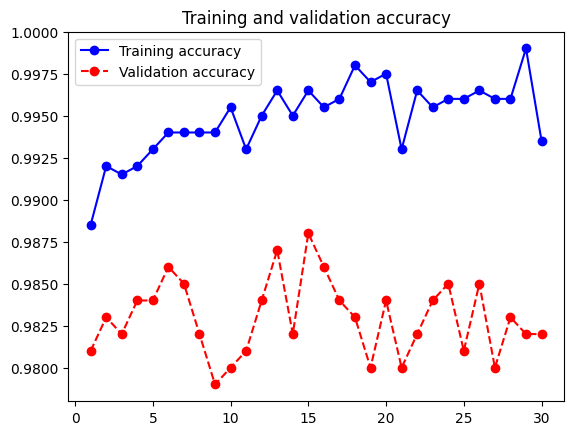

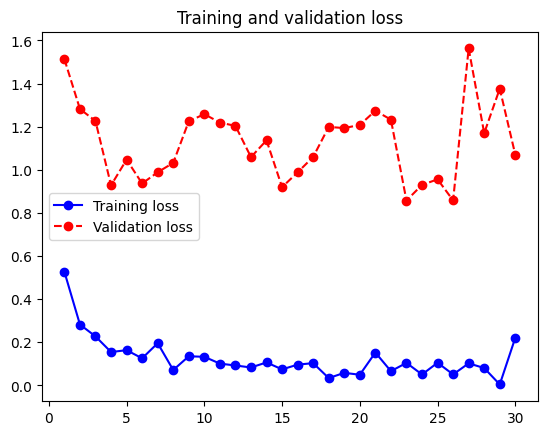

In [22]:
plot(history)

In [23]:
model = keras.models.load_model("models/U3-CNNs/dogs-vs-cats_fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset) 
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 632ms/step - accuracy: 0.9791 - loss: 1.3055
Test accuracy: 0.978


* The results now are slightly better than in the feature extraction approach (sometimes not).

## 3.9. Residual networks

### 3.9.1. Very deep networks and vanishing gradients

#### Very deep networks

* We can see that the deeper the network, the larger its learning capacity, and the better it extracts features from images.
* Modern CNN architectures tend to have more layers in each development, see how CNNs evolved from LeNet, through AlexNet, VGGNet to Inception (GoogLeNet).
    
![deeper.jpg](images/CNNs/deeper.jpg)

* __Problems__
    * One downside of adding too many layers is that doing so makes the network more prone to __overfit__ the training data. 
    * This is not a major problem because we can use regularization techniques to avoid overfitting: dropout, L2 regularization, batch normalization, etc.
    * But we need to fix just one other problem, to unblock the capability of building super-deep networks: a phenomenon called __vanishing gradients__.

#### Vanishing gradients

* We have already seen that __Vanishing gradients__ are a problem that occurs when the variations in the weights after each iteration are very small, causing the optimization of the loss function to be very slow or, in the worst case, to stop the learning of the neural network altogether.
* In very deep networks this can occur because as the network backpropagates the gradient of the error from the final layer back to the first layer, it is multiplied by the weight matrix at each step; thus the gradient can decrease exponentially quickly to zero, leading to a vanishing gradient phenomenon that prevents the earlier layers from learning. 

![vanishing_gradient_back.gif](images/CNNs/vanishing_gradient_back.gif)

### 3.9.2. Residual connections

* To solve the vanishing gradient problem, He et al. created a shortcut that allows the gradient to be directly backpropagated to earlier layers. 
* They are used to flow information from earlier layers in the network to later layers, creating an alternate shortcut path for the gradient to flow through.
<!-- Another important benefit of the skip connections is that they allow the model to learn an identity function, which ensures that the layer will perform at least as well as the previous layer -->
* Normally the residual connection is added before applying the ReLU activation function.

![residual_connections_1.png](images/CNNs/residual_connections_1.png)

#### Dimensionality problems

* The residual pseudocode is as follows:
```
x = ...
residual = x            # last output saved as residual
x = block(x)            # calculation of a new convolutional block
x = add([x, residual])  # additon of the residual and the convolutional block 
```
* But this code is not taking into account that the residual connection and the output of the convolutional block have different dimensions.
* We need to adjust the depth and the size of the residual network before performing the addition.

#### Adjusting the depth

* In the next code we can see that the residual connection is the output of a convolution with size 30x30 and a depth of 32 filters.
* If we perform another convolution (using the `same` padding to avoid downsampling) and using an increased number of filters (64), the output will have a shape of 30x30x64.
* In such cases, use a 1x1 Conv2D layer with no activation to linearly project the residual to the desired output shape.

In [24]:
from keras import layers
  
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu")(inputs)
residual = x
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
residual = layers.Conv2D(64, 1)(residual)
x = layers.add([x, residual])

![residual_depth.png](images/CNNs/residual_depth.png)

#### Adjusting the size

* If we include max-pooling layers then we need to adjust also the size.
* In this case we use also strides in the residual projection to match any downsampling caused by a max pooling layer.

In [25]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu")(inputs)
residual = x
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)
residual = layers.Conv2D(64, 1, strides=2)(residual)
x = layers.add([x, residual])

![residual_size.png](images/CNNs/residual_size.png)

* As an example, we can see next a simple CNN structured into a series of blocks, each made of two convolution layers and one optional max pooling layer, with a residual connection around each block:

In [26]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(inputs)

# Utility function to apply a convolutional block with 
# a residual connection, with an option to add max pooling
def residual_block(x, filters, pooling=False):
    residual = x
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    if pooling: # if pooling we use strides in the residual connection
        x = layers.MaxPooling2D(2, padding="same")(x)
        residual = layers.Conv2D(filters, 1, strides=2)(residual)
    elif filters != residual.shape[-1]:
        residual = layers.Conv2D(filters, 1)(residual)
    x = layers.add([x, residual])
    return x
  
x = residual_block(x, filters=32, pooling=True)
x = residual_block(x, filters=64, pooling=True)
x = residual_block(x, filters=128, pooling=False)

# The last block doesn’t need a max pooling layer, 
# since we will apply global average pooling right after it.
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 32, 32, 3) │          0 │ input_layer_7[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │        128 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │     18,496 │ add_3[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │     36,928 │ conv2d_9[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 64)  │      2,112 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 8, 8, 64)  │          0 │ max_pooling2d_2[… │
│                     │                   │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 128) │    147,584 │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 8, 8, 128) │      8,320 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 8, 8, 128) │          0 │ conv2d_13[0][0],  │
│                     │                   │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_5[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 297,697 (1.14 MB)

 Trainable params: 297,697 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

* With residual connections, we can build networks of arbitrary depth, without having to worry about vanishing gradients.

![ResNet34.png](images/CNNs/ResNet34.png)